# Appendicitis Prediction — AdaptiveRAMAS (MCA) vs RAMAAS Baseline

**PCA/MCA Framing:**
- **Algorithm**: Multiple Correspondence Analysis (MCA) — PCA For
 binary/categorical data
- **Input**: Binary feature vector ของอาการผู้ป่วย 7 features
- **Output**: probability + Risk Level (Very Low / Low / Moderate / High)
- **Adaptive Mechanism**: ปรับ RAMA-AS weights ตาม MCA PC1 loadings จาก context

**เหตุผลที่ใช้ MCA แทน PCA ปกติ:**
- PCA assume continuous data และ linear relationship — features ทั้ง 7 ตัวเป็น binary (0/1)
- MCA ใช้ Burt matrix (Z'Z) แทน covariance matrix — ออกแบบมาสำหรับ categorical data โดยเฉพาะ
- PC1 loadings จาก MCA สะท้อน feature importance จริงในบริบทของ binary data

**3 Adaptive Methods:**
1. **Feature Weighting** — MCA PC1 loadings → adjustment factor → ปรับ RAMA-AS weights
2. **Sequential Pattern** — วิเคราะห์ว่า PC1 loadings drift ตาม batch หรือไม่
3. **Outlier Detection** — หาเคสที่มี feature pattern หายากเพื่อให้แพทย์ review

## Cell 1 — Import Libraries

In [11]:
import pandas as pd
import numpy as np
import pickle
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
np.random.seed(42)

## Cell 2 — Constants & Helper Functions

In [12]:
# ---- Features ----
BASE_FEATURES = ['Migration', 'Progression', 'Aggravation', 'TEMP', 'Rebound', 'WBC', 'Neut']
TARGET        = 'appendicitis'

# ---- RAMA-AS Base Weights (จากสมการ Logistic Regression ดั้งเดิม) ----
# BASE_WEIGHTS = np.array([0.80, 1.04, 0.78, 1.64, 1.53, 0.91, 0.69])
# INTERCEPT    = -3.37

BASE_WEIGHTS = np.array([-0.0310, 0.6474, -0.0868, -0.7714, 1.1534, 0.9001, 1.1809])
INTERCEPT    = -1.1638

# ---- Risk Stratification Cutoffs (logit score) ----

RISK_CUTOFFS = {
    'Very Low Risk': (-np.inf, -0.64),
    'Low Risk':      (-0.64,   0.84),
    'Moderate Risk': (0.85,    1.74),
    'High Risk':     (1.74,    np.inf)
}
POST_TEST_PROB  = {'Very Low Risk': '< 76%', 'Low Risk': '76%',
                   'Moderate Risk': '89%',   'High Risk': '93%'}
RECOMMENDATION  = {'Very Low Risk': 'Discharge',
                   'Low Risk':      'Out-patient Observation',
                   'Moderate Risk': 'Ultrasound / CT scan',
                   'High Risk':     'Surgical treatment'}
RISK_ORDER = ['Very Low Risk', 'Low Risk', 'Moderate Risk', 'High Risk']

# ---- MCA Parameters ----
ADJUSTMENT_CAP = 0.30   
K_FOLDS        = 5
N_BATCHES      = 5      
DRIFT_THRESHOLD = 0.05  


def get_risk_level(logit_score):
    """แปลง logit score เป็น risk level ตาม RAMA-AS cutoffs"""
    if logit_score < -0.64:
        return 'Very Low Risk'
    elif logit_score <= 0.84:
        return 'Low Risk'
    elif logit_score <= 1.74:
        return 'Moderate Risk'
    else:
        return 'High Risk'


def calc_metrics(y_true, preds, scores):
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    total = len(y_true)
    acc   = (tp + tn) / total
    sens  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1    = 2 * prec * sens / (prec + sens) if (prec + sens) > 0 else 0.0
    auc   = roc_auc_score(y_true, scores) if len(np.unique(y_true)) > 1 else float('nan')
    return dict(TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Accuracy=acc, Sensitivity=sens, Specificity=spec, F1=f1, AUC=auc)


def evaluate_ramaas_baseline(df, y_true, threshold=0.5):
    """ประเมิน RAMA-AS ด้วย base weights ดั้งเดิม"""
    X = df[BASE_FEATURES].values.astype(float)
    logit = INTERCEPT + X @ BASE_WEIGHTS
    probs = 1 / (1 + np.exp(-logit))
    preds = (probs >= threshold).astype(int)
    return calc_metrics(y_true, preds, probs)


print(f"   Features: {BASE_FEATURES}")
print(f"   Base weights: {dict(zip(BASE_FEATURES, BASE_WEIGHTS))}")
print(f"   Intercept: {INTERCEPT}")

   Features: ['Migration', 'Progression', 'Aggravation', 'TEMP', 'Rebound', 'WBC', 'Neut']
   Base weights: {'Migration': -0.031, 'Progression': 0.6474, 'Aggravation': -0.0868, 'TEMP': -0.7714, 'Rebound': 1.1534, 'WBC': 0.9001, 'Neut': 1.1809}
   Intercept: -1.1638


## Cell 3 — BinaryMCA Architecture

In [13]:
class BinaryMCA:
    """
    Multiple Correspondence Analysis (MCA) สำหรับ binary features

    ทำไมต้องใช้ MCA แทน PCA:
    - PCA: ใช้ covariance matrix → assume continuous, normally distributed data
    - MCA: ใช้ Burt matrix (Z'Z) → ออกแบบสำหรับ categorical/binary data โดยเฉพาะ
    - สำหรับ binary features: MCA loadings สะท้อน feature co-occurrence pattern จริง

    กระบวนการ:
    1. สร้าง Indicator matrix Z = [1-X | X]  shape (n, 2p)
    2. คำนวณ Burt matrix B = Z'Z / n         shape (2p, 2p)
    3. Eigendecomposition ของ B
    4. PC1 loadings = eigenvector ที่สอดคล้องกับ eigenvalue สูงสุด
       (เอาเฉพาะ rows ที่สอดคล้องกับ X=1 categories)
    """

    def __init__(self):
        self.eigenvalues_ = None
        self.loadings_ = None
        self.explained_variance_ratio_ = None
        self.n_features_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n, p = X.shape
        self.n_features_ = p

        # Indicator matrix
        Z = np.hstack([1 - X, X])  # (n, 2p)

        # Burt matrix
        B = Z.T @ Z / n  # (2p, 2p)

        # Eigendecomposition
        eigenvalues, eigenvectors = np.linalg.eigh(B)
        idx = np.argsort(eigenvalues)[::-1]
        self.eigenvalues_ = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.loadings_ = eigenvectors[p:, :]

        total = self.eigenvalues_.sum()
        self.explained_variance_ratio_ = (
            self.eigenvalues_ / total if total > 0 else self.eigenvalues_
        )
        return self

    def get_pc1_loadings(self):
        """คืน absolute loading ของแต่ละ feature บน PC1"""
        return np.abs(self.loadings_[:, 0])

    def reconstruction_error(self, X, n_components=None): #Outlier Detection

        X = np.asarray(X, dtype=float)
        n, p = X.shape
        Z = np.hstack([1 - X, X])

        if n_components is None:
            cumvar = np.cumsum(self.explained_variance_ratio_)
            n_components = int(np.searchsorted(cumvar, 0.80)) + 1
            n_components = min(n_components, 2 * p - 1)

        L   = self.loadings_[:, :n_components]
        Z1  = Z[:, p:]  # X=1 part
        Z1_hat = Z1 @ L @ L.T
        error  = np.mean((Z1 - Z1_hat) ** 2, axis=1)
        return error, n_components

## Cell 4 — Load Data

In [ ]:
df_train = pd.read_csv("C:/Users/User/Desktop/PCA final/dataset/TRAIN_DATASET.csv")
df_test  = pd.read_csv("C:/Users/User/Desktop/PCA final/dataset/TEST_DATASET.csv")

train_X = df_train[BASE_FEATURES].values.astype(float)
y_train = df_train[TARGET].values

test_X  = df_test[BASE_FEATURES].values.astype(float)
y_test  = df_test[TARGET].values

print(f"Train (bootstrap): {len(y_train)} samples "
      f"(pos={y_train.sum()}, neg={(y_train==0).sum()}) "
      f"rate={y_train.mean():.1%}")
print(f"Test  (real data): {len(y_test)} samples "
      f"(pos={y_test.sum()}, neg={(y_test==0).sum()}) "
      f"rate={y_test.mean():.1%}")
print(f"Feature vector size: {train_X.shape[1]}")

Train (bootstrap): 500 samples (pos=348, neg=152) rate=69.6%
Test  (real data): 376 samples (pos=266, neg=110) rate=70.7%
Feature vector size: 7


## Cell 5 — Method 1: Adaptive Feature Weighting (MCA)

In [15]:
from scipy.optimize import minimize
from scipy import stats as scipy_stats

def train_mca_adaptive(X_train, y_train, context_label='context'):
    # Step 1: MCA
    mca = BinaryMCA()
    mca.fit(X_train)
    pc1_loadings = mca.get_pc1_loadings()
    explained    = mca.explained_variance_ratio_[0]

    # Step 2: MCA + Correlation → initial guess
    correlations = np.array([
        abs(scipy_stats.pointbiserialr(X_train[:, i], y_train)[0])
        for i in range(X_train.shape[1])
    ])
    if correlations.max() > 0:
        correlations /= correlations.max()

    combined  = pc1_loadings * correlations
    mn, mx    = combined.min(), combined.max()
    normalized = (combined - mn) / (mx - mn) if mx > mn else np.ones_like(combined) / len(combined)
    normalized /= normalized.mean()

    init_adj = np.clip(1.0 + ADJUSTMENT_CAP * (normalized - 1.0),
                       1 - ADJUSTMENT_CAP, 1 + ADJUSTMENT_CAP)

    # Step 3: Optimize → maximize AUC บน train data (constraint ±30%)
    def neg_auc(adj):
        prob = 1 / (1 + np.exp(-(INTERCEPT + X_train @ (BASE_WEIGHTS * adj))))
        try:    return -roc_auc_score(y_train, prob)
        except: return 0.0

    bounds = [(1 - ADJUSTMENT_CAP, 1 + ADJUSTMENT_CAP)] * len(BASE_WEIGHTS)
    result = minimize(neg_auc, init_adj, method='L-BFGS-B', bounds=bounds)

    adjustment = result.x
    adapted_w  = BASE_WEIGHTS * adjustment
    return mca, pc1_loadings, adjustment, adapted_w, explained


def predict_adaptive(X, adapted_weights, threshold=0.5):
    logit = INTERCEPT + X @ adapted_weights
    prob  = 1 / (1 + np.exp(-logit))
    return prob, logit, (prob >= threshold).astype(int)


def predict_with_risk(X, adapted_weights):
    prob, logit, pred = predict_adaptive(X, adapted_weights)
    risks = [get_risk_level(s) for s in logit]
    return prob, logit, pred, risks, [POST_TEST_PROB[r] for r in risks], [RECOMMENDATION[r] for r in risks]


# Train
mca_model, pc1_loadings, adjustment, adapted_w, explained = train_mca_adaptive(
    train_X, y_train, context_label='train_context'
)

print(f"\nPC1 Explained Variance: {explained:.1%}")
print(f"\n{'Feature':<14} {'Base W':>8} {'PC1 Load':>10} {'Adjust':>8} {'New W':>8}")
print("-" * 52)
for feat, bw, load, adj in zip(BASE_FEATURES, BASE_WEIGHTS, pc1_loadings, adjustment):
    print(f"{feat:<14} {bw:>8.4f} {load:>10.4f} {adj:>8.3f}x {bw*adj:>8.3f}")



PC1 Explained Variance: 62.1%

Feature          Base W   PC1 Load   Adjust    New W
----------------------------------------------------
Migration       -0.0310     0.3557    0.841x   -0.026
Progression      0.6474     0.3263    1.044x    0.676
Aggravation     -0.0868     0.4528    0.802x   -0.070
TEMP            -0.7714     0.1854    0.700x   -0.540
Rebound          1.1534     0.2955    1.125x    1.298
WBC              0.9001     0.3848    1.287x    1.159
Neut             1.1809     0.3314    1.201x    1.418


## Cell 6 — K-Fold Cross Validation (K=5)

In [16]:
skf        = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
cv_results = []

print(f"{K_FOLDS}-Fold CV (AdaptiveRAMAS MCA)\n")

for fold, (tr_idx, val_idx) in enumerate(skf.split(train_X, y_train), 1):
    X_tr, y_tr = train_X[tr_idx], y_train[tr_idx]
    X_val, y_val = train_X[val_idx], y_train[val_idx]

    _, _, _, fold_w, _ = train_mca_adaptive(X_tr, y_tr)

    prob_val, _, pred_val = predict_adaptive(X_val, fold_w)
    m = calc_metrics(y_val, pred_val, prob_val)
    cv_results.append(m)

    print(f"Fold {fold}: Sens={m['Sensitivity']:.2%}  Spec={m['Specificity']:.2%}  "
          f"F1={m['F1']:.4f}  FN={m['FN']}  FP={m['FP']}")

5-Fold CV (AdaptiveRAMAS MCA)

Fold 1: Sens=90.00%  Spec=26.67%  F1=0.8129  FN=7  FP=22
Fold 2: Sens=98.57%  Spec=43.33%  F1=0.8846  FN=1  FP=17
Fold 3: Sens=95.71%  Spec=46.67%  F1=0.8758  FN=3  FP=16
Fold 4: Sens=97.10%  Spec=32.26%  F1=0.8535  FN=2  FP=21
Fold 5: Sens=86.96%  Spec=29.03%  F1=0.7947  FN=9  FP=22


## Cell 7 — สรุปผล CV + เปรียบเทียบ RAMAAS Baseline

In [17]:
# CV Summary
metric_keys = ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC', 'FN', 'FP']
cv_row = {'Model': 'AdaptiveRAMAS MCA (CV)'}
for k in metric_keys:
    vals = [f[k] for f in cv_results]
    m, s = np.mean(vals), np.std(vals)
    cv_row[k] = (f"{m:.1f}±{s:.1f}" if k in ['FN', 'FP'] else
                 f"{m:.4f}±{s:.4f}" if k in ['F1', 'AUC'] else
                 f"{m:.2%}±{s:.2%}")

print("\n" + "=" * 110)
print(f" {K_FOLDS}-Fold CV — AdaptiveRAMAS MCA (Mean ± Std)")
print("=" * 110)
print(pd.DataFrame([cv_row]).to_string(index=False))
print("=" * 110)

# Evaluate
print("\nEvaluate on Test Set")
prob_adapt, logit_adapt, pred_adapt, risks_adapt, ptps_adapt, recs_adapt = \
    predict_with_risk(test_X, adapted_w)

# Baseline
logit_base = INTERCEPT + test_X @ BASE_WEIGHTS
prob_base  = 1 / (1 + np.exp(-logit_base))
pred_base  = (prob_base >= 0.5).astype(int)

ramaas_result  = calc_metrics(y_test, pred_base,  prob_base)
adaptive_result = calc_metrics(y_test, pred_adapt, prob_adapt)

# Comparison table
rows = []
for name, m in [('RAMAAS (Baseline)', ramaas_result),
                ('AdaptiveRAMAS MCA', adaptive_result)]:
    rows.append({'Model': name,
                 'Accuracy':    f"{m['Accuracy']:.2%}",
                 'Sensitivity': f"{m['Sensitivity']:.2%}",
                 'Specificity': f"{m['Specificity']:.2%}",
                 'F1':          f"{m['F1']:.4f}",
                 'AUC':         f"{m['AUC']:.4f}",
                 'TP': m['TP'], 'TN': m['TN'],
                 'FP': m['FP'], 'FN': m['FN']})

print("\n" + "=" * 100)
print(" RAMAAS vs AdaptiveRAMAS MCA — Test Set")
print("=" * 100)
print(pd.DataFrame(rows).to_string(index=False))
print("=" * 100)

print("\nComparison (Adaptive − Baseline):")
for met in ['Accuracy', 'Sensitivity', 'Specificity', 'F1', 'AUC']:
    diff = adaptive_result[met] - ramaas_result[met]
    print(f"  {met:<12}: {'↑' if diff > 0 else '↓'} {abs(diff):.4f}")
print(f"  FN change   : {adaptive_result['FN'] - ramaas_result['FN']:+d} ราย")
print(f"  FP change   : {adaptive_result['FP'] - ramaas_result['FP']:+d} ราย")

# Risk Stratification
print(f"\n{'='*80}")
print(" Risk Stratification (logit cutoffs: <-0.64 / -0.64-0.84 / 0.85-1.74 / >1.74)")
print(f"{'='*80}")
risks_base = [get_risk_level(s) for s in logit_base]
print(f"{'Risk Level':<18} {'Post-test':>10} {'Action':<26} {'Baseline':>14} {'Adaptive':>14}")
print("-" * 86)
for level in RISK_ORDER:
    nb_ = sum(1 for r in risks_base  if r == level)
    na_ = sum(1 for r in risks_adapt if r == level)
    rb_ = np.mean([y for r, y in zip(risks_base,  y_test) if r == level]) if nb_ > 0 else np.nan
    ra_ = np.mean([y for r, y in zip(risks_adapt, y_test) if r == level]) if na_ > 0 else np.nan
    print(f"{level:<18} {POST_TEST_PROB[level]:>10} {RECOMMENDATION[level]:<26} "
          f"n={nb_:>3}({rb_:.0%}){'':<2} n={na_:>3}({ra_:.0%})")


 5-Fold CV — AdaptiveRAMAS MCA (Mean ± Std)
                 Model     Accuracy  Sensitivity  Specificity            F1           AUC      FN       FP
AdaptiveRAMAS MCA (CV) 76.00%±5.22% 93.67%±4.44% 35.59%±7.95% 0.8443±0.0351 0.7765±0.0501 4.4±3.1 19.6±2.6

Evaluate on Test Set

 RAMAAS vs AdaptiveRAMAS MCA — Test Set
            Model Accuracy Sensitivity Specificity     F1    AUC  TP  TN  FP  FN
RAMAAS (Baseline)   76.33%      90.23%      42.73% 0.8436 0.7555 240  47  63  26
AdaptiveRAMAS MCA   76.60%      94.36%      33.64% 0.8508 0.7584 251  37  73  15

Comparison (Adaptive − Baseline):
  Accuracy    : ↑ 0.0027
  Sensitivity : ↑ 0.0414
  Specificity : ↓ 0.0909
  F1          : ↑ 0.0073
  AUC         : ↑ 0.0030
  FN change   : -11 ราย
  FP change   : +10 ราย

 Risk Stratification (logit cutoffs: <-0.64 / -0.64-0.84 / 0.85-1.74 / >1.74)
Risk Level          Post-test Action                           Baseline       Adaptive
-------------------------------------------------------------

## Cell 8 — Visualization

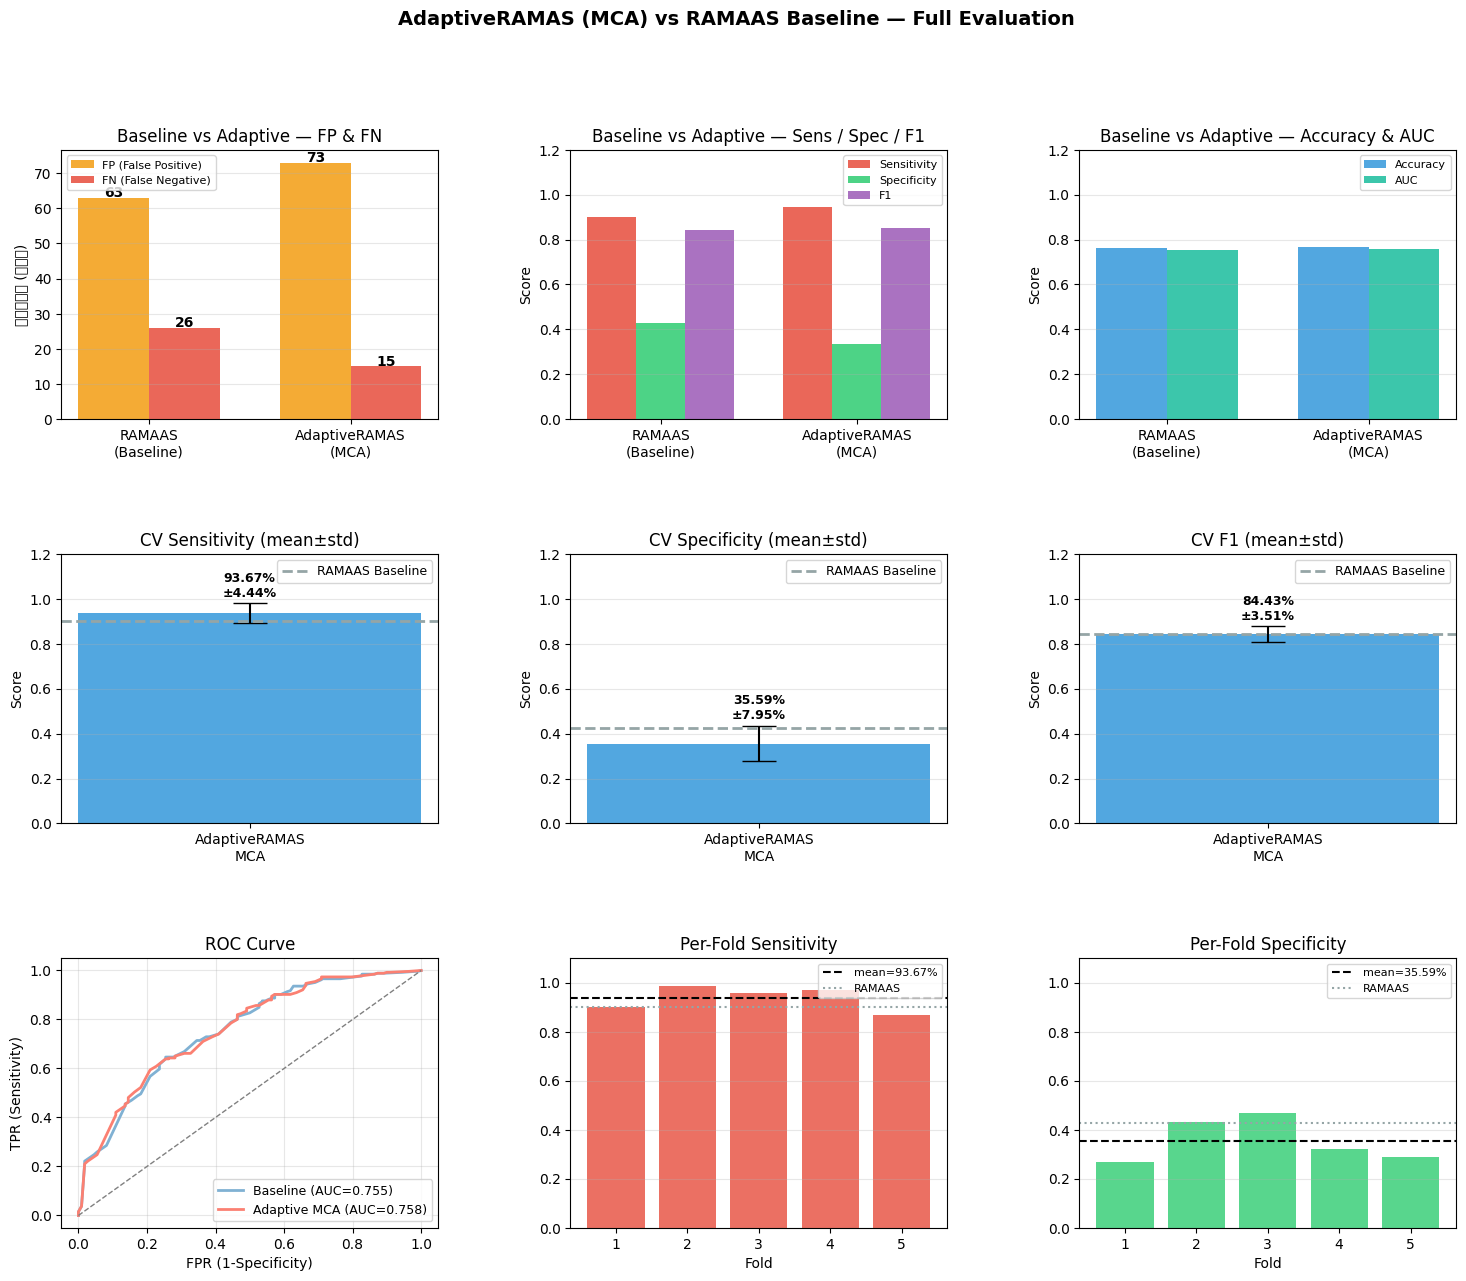

In [18]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)

cmp_data   = [ramaas_result, adaptive_result]
cmp_labels = ['RAMAAS\n(Baseline)', 'AdaptiveRAMAS\n(MCA)']
x2, w = np.arange(2), 0.35
COLOR_BASE  = '#80b1d3'
COLOR_ADAPT = '#fb8072'

# Row 1: FP & FN
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x2 - w/2, [m['FP'] for m in cmp_data], w,
        label='FP (False Positive)',   color='#f39c12', alpha=0.85)
ax1.bar(x2 + w/2, [m['FN'] for m in cmp_data], w,
        label='FN (False Negative)', color='#e74c3c', alpha=0.85)
ax1.set_xticks(x2); ax1.set_xticklabels(cmp_labels)
ax1.set_title('Baseline vs Adaptive — FP & FN')
ax1.set_ylabel('จำนวน (ราย)')
ax1.legend(fontsize=8); ax1.grid(axis='y', alpha=0.3)
for i, m in enumerate(cmp_data):
    ax1.text(i - w/2, m['FP'] + 0.3, str(m['FP']),
             ha='center', fontsize=10, fontweight='bold')
    ax1.text(i + w/2, m['FN'] + 0.3, str(m['FN']),
             ha='center', fontsize=10, fontweight='bold')

# Row 1: Sens / Spec / F1
ax2 = fig.add_subplot(gs[0, 1])
for j, (met, col) in enumerate(zip(
        ['Sensitivity', 'Specificity', 'F1'],
        ['#e74c3c', '#2ecc71', '#9b59b6'])):
    ax2.bar(x2 + (j-1) * 0.25, [m[met] for m in cmp_data],
            0.25, label=met, color=col, alpha=0.85)
ax2.set_xticks(x2); ax2.set_xticklabels(cmp_labels)
ax2.set_ylim(0, 1.2)
ax2.set_title('Baseline vs Adaptive — Sens / Spec / F1')
ax2.set_ylabel('Score'); ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

# Row 1: Accuracy & AUC
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(x2 - w/2, [m['Accuracy'] for m in cmp_data], w,
        label='Accuracy', color='#3498db', alpha=0.85)
ax3.bar(x2 + w/2, [m['AUC']      for m in cmp_data], w,
        label='AUC',      color='#1abc9c', alpha=0.85)
ax3.set_xticks(x2); ax3.set_xticklabels(cmp_labels)
ax3.set_ylim(0, 1.2)
ax3.set_title('Baseline vs Adaptive — Accuracy & AUC')
ax3.set_ylabel('Score'); ax3.legend(fontsize=8); ax3.grid(axis='y', alpha=0.3)

# Row 2: CV Mean ± Std
for col_idx, (met, title) in enumerate(zip(
        ['Sensitivity', 'Specificity', 'F1'],
        ['CV Sensitivity (mean±std)', 'CV Specificity (mean±std)', 'CV F1 (mean±std)'])):
    ax = fig.add_subplot(gs[1, col_idx])
    mv = np.mean([f[met] for f in cv_results])
    sv = np.std( [f[met] for f in cv_results])
    ax.bar([0], [mv], color='#3498db', alpha=0.85,
           yerr=[sv], capsize=12, width=0.4)
    ax.axhline(ramaas_result[met], color='#95a5a6',
               linestyle='--', linewidth=2, label='RAMAAS Baseline')
    ax.set_xticks([0]); ax.set_xticklabels(['AdaptiveRAMAS\nMCA'])
    ax.set_ylim(0, 1.2); ax.set_title(title)
    ax.set_ylabel('Score'); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
    ax.text(0, mv + sv + 0.03, f"{mv:.2%}\n±{sv:.2%}",
            ha='center', fontsize=9, fontweight='bold')

# Row 3: ROC Curve
ax_roc = fig.add_subplot(gs[2, 0])
fpr_b, tpr_b, _ = roc_curve(y_test, prob_base)
fpr_a, tpr_a, _ = roc_curve(y_test, prob_adapt)
ax_roc.plot(fpr_b, tpr_b, color=COLOR_BASE,  lw=2,
            label=f'Baseline (AUC={ramaas_result["AUC"]:.3f})')
ax_roc.plot(fpr_a, tpr_a, color=COLOR_ADAPT, lw=2,
            label=f'Adaptive MCA (AUC={adaptive_result["AUC"]:.3f})')
ax_roc.plot([0, 1], [0, 1], 'gray', lw=1, linestyle='--')
ax_roc.set_xlabel('FPR (1-Specificity)'); ax_roc.set_ylabel('TPR (Sensitivity)')
ax_roc.set_title('ROC Curve'); ax_roc.legend(fontsize=9); ax_roc.grid(alpha=0.3)

# Row 3: Per-fold Sensitivity
ax_f1 = fig.add_subplot(gs[2, 1])
fold_sens = [f['Sensitivity'] for f in cv_results]
ax_f1.bar(range(1, K_FOLDS + 1), fold_sens, color='#e74c3c', alpha=0.8)
ax_f1.axhline(np.mean(fold_sens), color='black', linestyle='--', linewidth=1.5,
              label=f"mean={np.mean(fold_sens):.2%}")
ax_f1.axhline(ramaas_result['Sensitivity'], color='#95a5a6',
              linestyle=':', linewidth=1.5, label='RAMAAS')
ax_f1.set_title('Per-Fold Sensitivity'); ax_f1.set_xlabel('Fold')
ax_f1.set_ylim(0, 1.1); ax_f1.legend(fontsize=8); ax_f1.grid(axis='y', alpha=0.3)

# Row 3: Per-fold Specificity
ax_f2 = fig.add_subplot(gs[2, 2])
fold_spec = [f['Specificity'] for f in cv_results]
ax_f2.bar(range(1, K_FOLDS + 1), fold_spec, color='#2ecc71', alpha=0.8)
ax_f2.axhline(np.mean(fold_spec), color='black', linestyle='--', linewidth=1.5,
              label=f"mean={np.mean(fold_spec):.2%}")
ax_f2.axhline(ramaas_result['Specificity'], color='#95a5a6',
              linestyle=':', linewidth=1.5, label='RAMAAS')
ax_f2.set_title('Per-Fold Specificity'); ax_f2.set_xlabel('Fold')
ax_f2.set_ylim(0, 1.1); ax_f2.legend(fontsize=8); ax_f2.grid(axis='y', alpha=0.3)

plt.suptitle('AdaptiveRAMAS (MCA) vs RAMAAS Baseline — Full Evaluation',
             fontsize=14, fontweight='bold')
plt.savefig('adaptive_ramas_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Method 2: Sequential Pattern Analysis (Temporal)

[Method 2 — Sequential Pattern Analysis]
Split 500 patient to 5 batches (100 person/batch)
Batch 1 (ราย 1-100) | n=100 | rate=76.0%
  Migration      0.3056
  Progression    0.3475
  Aggravation    0.4545
  TEMP           0.1767
  Rebound        0.3058
  WBC            0.3604
  Neut           0.3516

Batch 2 (ราย 101-200) | n=100 | rate=70.0%
  Migration      0.3471
  Progression    0.3012
  Aggravation    0.4448
  TEMP           0.1810
  Rebound        0.3068
  WBC            0.4220
  Neut           0.3444

Batch 3 (ราย 201-300) | n=100 | rate=61.0%
  Migration      0.3736
  Progression    0.3289
  Aggravation    0.4517
  TEMP           0.2075
  Rebound        0.2997
  WBC            0.3791
  Neut           0.3160

Batch 4 (ราย 301-400) | n=100 | rate=71.0%
  Migration      0.3712
  Progression    0.3118
  Aggravation    0.4519
  TEMP           0.1784
  Rebound        0.2954
  WBC            0.3969
  Neut           0.2879

Batch 5 (ราย 401-500) | n=100 | rate=70.0%
  Migration      0.3

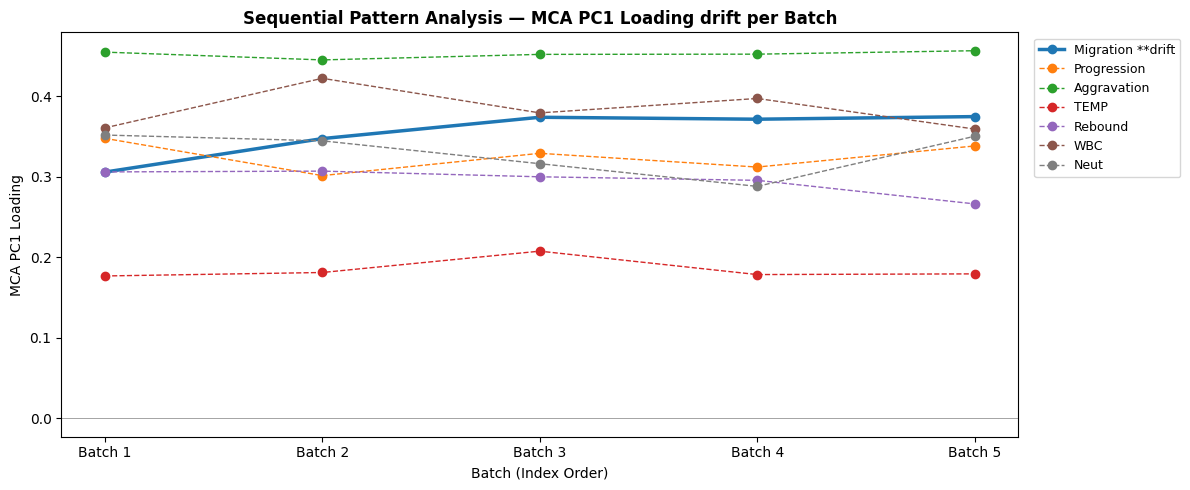

In [19]:
n = len(train_X)
batch_size = n // N_BATCHES
batch_loadings_all = []
batch_labels_all   = []

print(f"[Method 2 — Sequential Pattern Analysis]")
print(f"Split {n} patient to {N_BATCHES} batches ({batch_size} person/batch)")

for i in range(N_BATCHES):
    start = i * batch_size
    end   = (i + 1) * batch_size if i < N_BATCHES - 1 else n
    X_b   = train_X[start:end]
    y_b   = y_train[start:end]

    mca_b = BinaryMCA()
    mca_b.fit(X_b)
    load_b = mca_b.get_pc1_loadings()
    batch_loadings_all.append(load_b)
    label  = f"Batch {i+1}\n(ราย {start+1}-{end})"
    batch_labels_all.append(label)
    print(f"Batch {i+1} (ราย {start+1}-{end}) | n={end-start} | rate={y_b.mean():.1%}")
    for feat, load in zip(BASE_FEATURES, load_b):
        print(f"  {feat:<14} {load:.4f}")
    print()

# Drift Analysis
first_load = np.array(batch_loadings_all[0])
last_load  = np.array(batch_loadings_all[-1])
drift      = np.abs(last_load - first_load)

print(f"การเปลี่ยนแปลง PC1 loading (Batch 1 → Batch {N_BATCHES}):")
drifted = []
for feat, d, fl, ll in zip(BASE_FEATURES, drift, first_load, last_load):
    flag = '** DRIFT' if d > DRIFT_THRESHOLD else ''
    print(f"  {feat:<14} {fl:.4f} → {ll:.4f} | Δ={d:.4f} {flag}")
    if d > DRIFT_THRESHOLD:
        drifted.append(feat)

if drifted:
    print(f"\nตรวจพบ pattern drift ใน: {', '.join(drifted)}")
else:
    print(f"\nไม่พบ pattern drift — weights มีเสถียรภาพตลอด")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
colors_feat = plt.cm.tab10(np.linspace(0, 0.7, len(BASE_FEATURES)))
for j, (feat, col) in enumerate(zip(BASE_FEATURES, colors_feat)):
    vals    = [bl[j] for bl in batch_loadings_all]
    is_drift = feat in drifted
    ax.plot(range(1, N_BATCHES + 1), vals, marker='o', color=col,
            lw=2.5 if is_drift else 1.0,
            ls='-' if is_drift else '--',
            label=f"{feat}{' **drift' if is_drift else ''}")

ax.set_xticks(range(1, N_BATCHES + 1))
ax.set_xticklabels([f'Batch {i}' for i in range(1, N_BATCHES + 1)])
ax.set_xlabel('Batch (Index Order)')
ax.set_ylabel('MCA PC1 Loading')
ax.set_title('Sequential Pattern Analysis — MCA PC1 Loading drift per Batch',
             fontsize=12, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.axhline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.savefig('adaptive_ramas_sequential.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 10 — Method 3: Outlier Detection + MCA Feature Importance

[Method 3 — Outlier Detection]

Rare Pattern Detection (reference=train):
  Train: 500 cases, 63 unique patterns / 128
  Rare threshold: ≤ 5 cases (<1% ของ train)
  ตรวจพบ atypical ใน test set: 79 เคส (21.0%)
  ตัวอย่างเคสที่ควร review:
    ลำดับที่ 1: ไม่เคยพบใน train | อาการ: Progression, Aggravation, TEMP, Neut
    ลำดับที่ 6: พบแค่ 3 ครั้ง | อาการ: Aggravation, TEMP, WBC
    ลำดับที่ 10: พบแค่ 5 ครั้ง | อาการ: Progression, Aggravation, TEMP, Rebound, WBC, Neut
    ลำดับที่ 15: พบแค่ 1 ครั้ง | อาการ: Migration, Progression, Aggravation, Rebound, Neut
    ลำดับที่ 16: พบแค่ 5 ครั้ง | อาการ: Migration, Progression, Aggravation, TEMP, Neut

MCA Reconstruction Error (ไม่มี reference):
  n_components (≥80% var): 3
  Threshold (Q3+1.5×IQR): 0.3665
  ตรวจพบ atypical: 0 เคส (0.0%)

MCA PC1 Feature Importance vs Base Weights
Feature          Base W   PC1 Load   Adjust    New W
----------------------------------------------------
Aggravation       -0.09     0.4528    0.802x   -0.070
WBC      

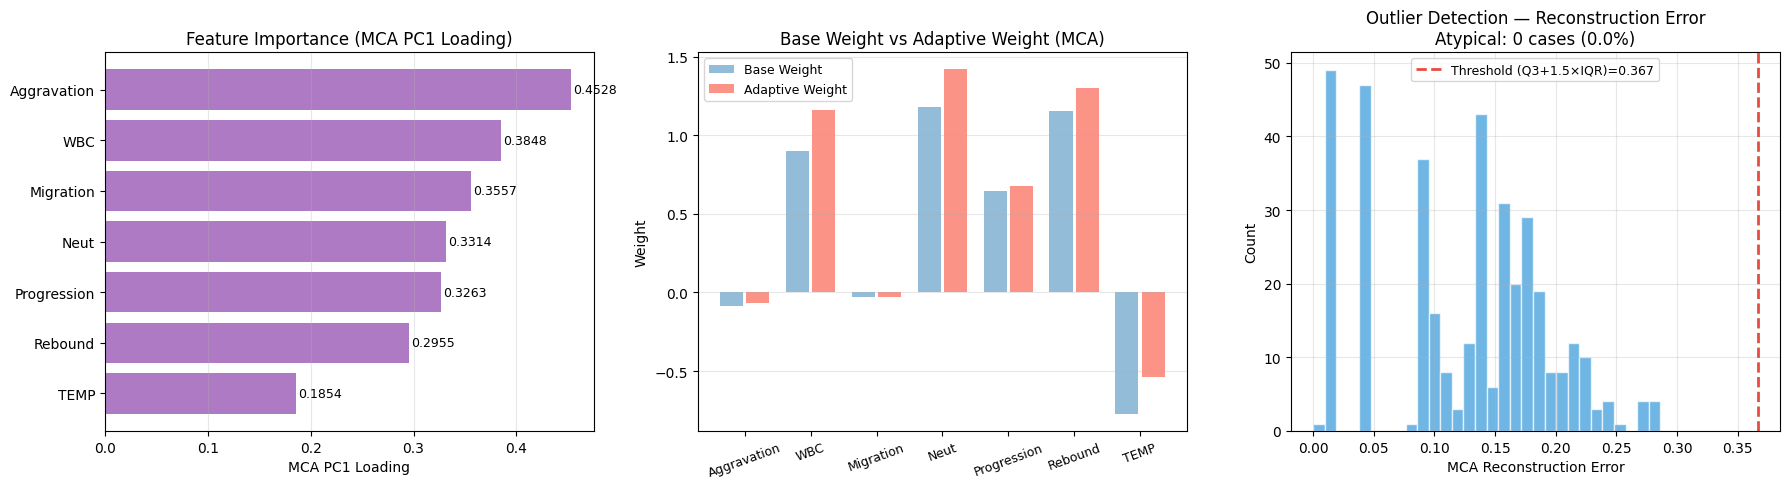

In [20]:
print("[Method 3 — Outlier Detection]")

# Rare Pattern Detection 
pattern_counts = Counter(map(tuple, train_X.astype(int)))
n_train        = len(train_X)
rare_threshold = max(1, int(n_train * 0.01))
n_unique_train = len(pattern_counts)

print(f"\nRare Pattern Detection (reference=train):")
print(f"  Train: {n_train} cases, {n_unique_train} unique patterns / 128")
print(f"  Rare threshold: ≤ {rare_threshold} cases (<1% ของ train)")

atypical_idx = []
rare_info    = []
for i, row in enumerate(test_X.astype(int)):
    pat   = tuple(row)
    count = pattern_counts.get(pat, 0)
    if count <= rare_threshold:
        atypical_idx.append(i)
        rare_info.append((i, pat, count))

print(f"  ตรวจพบ atypical ใน test set: {len(atypical_idx)} เคส "
      f"({len(atypical_idx)/len(test_X):.1%})")
if rare_info:
    print("  ตัวอย่างเคสที่ควร review:")
    for idx, pat, count in rare_info[:5]:
        status  = 'ไม่เคยพบใน train' if count == 0 else f'พบแค่ {count} ครั้ง'
        present = [f for f, v in zip(BASE_FEATURES, pat) if v == 1]
        print(f"    ลำดับที่ {idx}: {status} | อาการ: {', '.join(present) or 'ไม่มีเลย'}")

# MCA Reconstruction Error
print(f"\nMCA Reconstruction Error (ไม่มี reference):")
mca_test = BinaryMCA()
mca_test.fit(test_X)
errors, n_comp = mca_test.reconstruction_error(test_X)
q3        = np.percentile(errors, 75)
iqr_      = q3 - np.percentile(errors, 25)
threshold = q3 + 1.5 * iqr_
outliers_recon = np.where(errors > threshold)[0]
print(f"  n_components (≥80% var): {n_comp}")
print(f"  Threshold (Q3+1.5×IQR): {threshold:.4f}")
print(f"  ตรวจพบ atypical: {len(outliers_recon)} เคส "
      f"({len(outliers_recon)/len(test_X):.1%})")

# MCA PC1 Feature Importance
print("\n" + "="*55)
print("MCA PC1 Feature Importance vs Base Weights")
print("="*55)

feat_imp = []
for feat, bw, load, adj in zip(BASE_FEATURES, BASE_WEIGHTS, pc1_loadings, adjustment):
    feat_imp.append({
        'Feature':    feat,
        'Base_Weight': bw,
        'PC1_Loading': load,
        'Adjustment':  adj,
        'New_Weight':  bw * adj
    })

feat_imp = sorted(feat_imp, key=lambda x: x['PC1_Loading'], reverse=True)
print(f"{'Feature':<14} {'Base W':>8} {'PC1 Load':>10} {'Adjust':>8} {'New W':>8}")
print("-" * 52)
for r in feat_imp:
    print(f"{r['Feature']:<14} {r['Base_Weight']:>8.2f} "
          f"{r['PC1_Loading']:>10.4f} {r['Adjustment']:>8.3f}x {r['New_Weight']:>8.3f}")

# Plot: Feature Importance + Outlier Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

feat_names_sorted = [r['Feature']    for r in feat_imp]
pc1_sorted        = [r['PC1_Loading'] for r in feat_imp]
adj_sorted        = [r['Adjustment']  for r in feat_imp]
bw_sorted         = [r['Base_Weight'] for r in feat_imp]

# กราฟ 1: PC1 Loading (Feature Importance)
axes[0].barh(feat_names_sorted, pc1_sorted, color='#9b59b6', alpha=0.8)
axes[0].invert_yaxis()
axes[0].set_xlabel('MCA PC1 Loading')
axes[0].set_title('Feature Importance (MCA PC1 Loading)')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(pc1_sorted):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# กราฟ 2: Base vs New Weight
x_pos = np.arange(len(BASE_FEATURES))
axes[1].bar(x_pos - 0.2, bw_sorted,  0.35, label='Base Weight',  color='#80b1d3', alpha=0.85)
new_sorted = [r['New_Weight'] for r in feat_imp]
axes[1].bar(x_pos + 0.2, new_sorted, 0.35, label='Adaptive Weight', color='#fb8072', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(feat_names_sorted, rotation=20, fontsize=9)
axes[1].set_title('Base Weight vs Adaptive Weight (MCA)')
axes[1].set_ylabel('Weight'); axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

# กราฟ 3: Reconstruction Error Distribution
axes[2].hist(errors, bins=30, color='#3498db', alpha=0.7, edgecolor='white')
axes[2].axvline(threshold, color='#e74c3c', lw=2, linestyle='--',
               label=f'Threshold (Q3+1.5×IQR)={threshold:.3f}')
axes[2].set_xlabel('MCA Reconstruction Error')
axes[2].set_ylabel('Count')
axes[2].set_title(f'Outlier Detection — Reconstruction Error\n'
                  f'Atypical: {len(outliers_recon)} cases ({len(outliers_recon)/len(test_X):.1%})')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('adaptive_ramas_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Save model
model_state = {
    'base_weights':  BASE_WEIGHTS,
    'adapted_weights': adapted_w,
    'adjustment':    adjustment,
    'pc1_loadings':  pc1_loadings,
    'intercept':     INTERCEPT,
    'mca_model':     mca_model
}
with open('AdaptiveRAMAS_model.pkl', 'wb') as f:
    pickle.dump(model_state, f)